In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df= pd.read_csv('diamonds.csv')
df

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326.0
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326.0
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,NaN,327.0
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334.0
4,NaN,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335.0
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757.0
53936,0.72,Good,D,SI1,NaN,55.0,5.69,5.75,3.61,2757.0
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757.0
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757.0


**Counting Number of Missing Values**

In [ ]:
missing_per_column = df.isna().sum()
total_missing = missing_per_column.sum()

print(missing_per_column)
print("Total missing values:", total_missing)

carat      3117
cut           0
color         0
clarity       0
depth      6051
table      2097
x          5517
y          4064
z          5843
price      1549
dtype: int64
Total missing values: 28238


**Missing Values vs Tuples Distribution**

Number of tuples with specific missing values:
0    33820
1    15665
2     3102
3      261
4       14
5      942
6      132
7        4
Name: count, dtype: int64


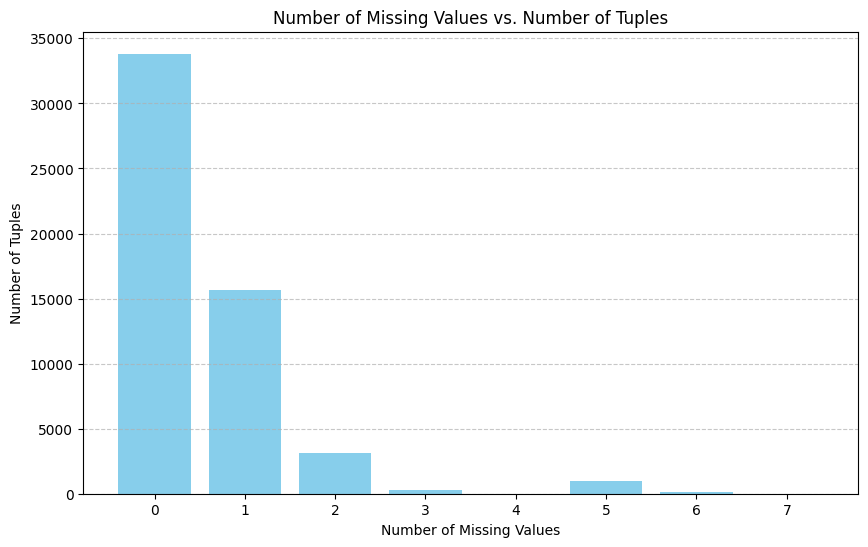

Number of tuples with >=50% of attributes missing: 1078
After dropping tuples with >=50% missing values, the dataset has 52862 rows.
After dropping tuples with missing 'quality' attribute, the dataset has 52083 rows.
Cleaned dataset saved as 'ciamonds_updated.csv'.


In [ ]:
missing_counts = df.isnull().sum(axis=1)

missing_value_distribution = missing_counts.value_counts().sort_index()

print("Number of tuples with specific missing values:")
print(missing_value_distribution)


plt.figure(figsize=(10, 6))
plt.bar(missing_value_distribution.index, missing_value_distribution.values, color='skyblue')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Tuples')
plt.title('Number of Missing Values vs. Number of Tuples')
plt.xticks(range(missing_value_distribution.index.min(), missing_value_distribution.index.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


threshold = len(df.columns) / 2

tuples_with_high_missing = (missing_counts >= threshold).sum()
print(f"Number of tuples with >=50% of attributes missing: {tuples_with_high_missing}")


df_cleaned = df[missing_counts < threshold]
print(f"After dropping tuples with >=50% missing values, the dataset has {len(df_cleaned)} rows.")


df_target_cleaned = df_cleaned.dropna(subset=['price'])
print(f"After dropping tuples with missing 'quality' attribute, the dataset has {len(df_target_cleaned)} rows.")

df_target_cleaned.to_csv('diamonds_updated.csv', index=False)
print("Cleaned dataset saved as 'ciamonds_updated.csv'.")


**Filling Missing Values through Median Imputation**

In [ ]:
df_filled_median = df_target_cleaned.fillna(df_target_cleaned.median())

print("Missing values replaced by the median of their respective attributes.")
print(df_filled_median.head())  # Display the first few rows of the updated dataset

# Verify if there are any missing values remaining
print("\nNumber of missing values in each attribute after replacement:")
print(df_filled_median.isnull().sum())


TypeError: Cannot convert [['Ideal' 'Premium' 'Good' ... 'Very Good' 'Premium' 'Ideal']
 ['E' 'E' 'E' ... 'D' 'H' 'D']
 ['SI2' 'SI1' 'VS1' ... 'SI1' 'SI2' 'SI2']] to numeric

In [ ]:
# Select only numeric columns for median computation
numeric_columns = df_target_cleaned.select_dtypes(include=['number']).columns

# Compute the median for numeric columns
medians = df_target_cleaned[numeric_columns].median()

# Fill missing values in numeric columns with their respective medians
df_filled_median = df_target_cleaned.copy()
df_filled_median[numeric_columns] = df_filled_median[numeric_columns].fillna(medians)

# Print the results
print("Missing values replaced by the median of their respective attributes.")
print(df_filled_median.head())  # Display the first few rows of the updated dataset

# Verify if there are any missing values remaining
print("\nNumber of missing values in each attribute after replacement:")
print(df_filled_median.isnull().sum())


Missing values replaced by the median of their respective attributes.
   carat      cut color clarity  depth  table     x     y     z  price
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43  326.0
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31  326.0
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  3.53  327.0
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63  334.0
4   0.70     Good     J     SI2   63.3   58.0  4.34  4.35  2.75  335.0

Number of missing values in each attribute after replacement:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64


Computing Statistics of the Updated Dataset

In [ ]:
df_processed = df_filled_median  # This is the DataFrame after filling missing values with median


# Compute statistics for the processed dataset
processed_stats = df_processed.describe().transpose()
processed_stats['Mode'] = df_processed.mode().iloc[0]

print(processed_stats['mean'], processed_stats['50%'], processed_stats['Mode'],processed_stats['std'])

carat       0.793049
depth      61.750738
table      57.446818
x           5.728127
y           5.729185
z           3.537946
price    3928.022637
Name: mean, dtype: float64 carat       0.70
depth      61.80
table      57.00
x           5.70
y           5.71
z           3.53
price    2401.00
Name: 50%, dtype: float64 carat      0.7
depth     61.8
table     57.0
x          5.7
y         5.71
z         3.53
price    802.0
Name: Mode, dtype: object carat       0.462601
depth       1.363398
table       2.210852
x           1.069675
y           1.106768
z           0.671857
price    3980.960366
Name: std, dtype: float64


**Forward Filling**

In [ ]:
# Replace missing values by propagating previous non-missing values
df_filled_propagated = df.fillna(method='ffill')

# Display the first few rows of the filled DataFrame
print("DataFrame after forward filling missing values:")
print(df_filled_propagated.head())

# Check if there are still missing values
missing_values_count = df_filled_propagated.isnull().sum().sum()
print(f"Total number of missing values after forward filling: {missing_values_count}")


DataFrame after forward filling missing values:
   carat      cut color clarity  depth  table     x     y     z  price
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43  326.0
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31  326.0
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31  327.0
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63  334.0
4   0.29     Good     J     SI2   63.3   58.0  4.34  4.35  2.75  335.0
Total number of missing values after forward filling: 0


/tmp/ipython-input-3300937527.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled_propagated = df.fillna(method='ffill')


In [ ]:
df_filled_propagated.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0


**Backward Filling**

In [ ]:
# Replace missing values by propagating previous non-missing values
df_bfilled_propagated = df.fillna(method='bfill')

# Display the first few rows of the filled DataFrame
print("DataFrame after backward filling missing values:")
print(df_bfilled_propagated.head())

# Check if there are still missing values
missing_values_count2 = df_bfilled_propagated.isnull().sum().sum()
print(f"Total number of missing values after backward filling: {missing_values_count2}")

DataFrame after backward filling missing values:
   carat      cut color clarity  depth  table     x     y     z  price
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43  326.0
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31  326.0
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.63  327.0
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63  334.0
4   0.24     Good     J     SI2   63.3   58.0  4.34  4.35  2.75  335.0
Total number of missing values after backward filling: 0


/tmp/ipython-input-2297049942.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfilled_propagated = df.fillna(method='bfill')


In [ ]:
df_bfilled_propagated.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0


**Linear Interpolation**

In [ ]:
# Replace missing values using linear interpolation
df_interpolated = df.interpolate(method='linear', axis=0)

# Display the first few rows of the interpolated DataFrame
print("DataFrame after linear interpolation:")
print(df_interpolated.head())

# Check for remaining missing values
missing_values_count = df_interpolated.isnull().sum().sum()
print(f"Total number of missing values after linear interpolation: {missing_values_count}")


DataFrame after linear interpolation:
   carat      cut color clarity  depth  table     x     y     z  price
0  0.230    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43  326.0
1  0.210  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31  326.0
2  0.230     Good     E     VS1   56.9   65.0  4.05  4.07  2.47  327.0
3  0.290  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63  334.0
4  0.265     Good     J     SI2   63.3   58.0  4.34  4.35  2.75  335.0
Total number of missing values after linear interpolation: 0


/tmp/ipython-input-1985728227.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df.interpolate(method='linear', axis=0)


In [ ]:
df_interpolated.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0
